# 04 - Classification with Decision Trees

**Input:** `student_processed.csv` (created in `01_preprocessing_eda.ipynb`)

**Task:** predict whether a student **passes** the course (`G3 >= 10`) or **fails** (`G3 < 10`) using decision trees, then extract human-readable decision rules and compare everything with simple baselines.

**Data-leakage safeguards**
- The stratified train/test split is the **first** modelling step. The test set is used exactly once, for the final evaluation.
- Hyper-parameters (`max_depth`, `min_samples_leaf`) are chosen by **cross-validation on the training set**. Selecting them on the test set would leak test information into the model.
- The features exclude `G3` (the target source) and the earlier grades `G1`, `G2`, `past_grades`, so the classifier relies on background and behaviour only (the *early-warning* setting). A final section shows how much the earlier grades would add.
- Decision trees are invariant to monotone feature transformations, so they need no scaling or outlier capping. The logistic-regression baseline, which does need them, uses a `Pipeline` where the cap and the scaler are fitted on the training data only.

## 1. Setup & Data Loading

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
PASS_THRESHOLD = 10
CLASS_NAMES = ["Fail", "Pass"]

DATA_PATH = Path("../data/student_processed.csv")

df = pd.read_csv(DATA_PATH)
assert df.isnull().sum().sum() == 0
print(f"Loaded {DATA_PATH.resolve()} - shape: {df.shape}")

Loaded A:\US\Semestr5\Szkoła Zimowa\Projekt\Repo\Data-science\data\student_processed.csv - shape: (395, 44)


### Custom transformer (used only by the logistic-regression baseline)

In [3]:
class QuantileCapper(BaseEstimator, TransformerMixin):
    """Cap (winsorize) the upper tail of selected columns at a quantile learned from the training data.

    The cap is computed in fit() and applied in transform(), so test data never influences it.
    """

    def __init__(self, columns, quantile=0.95):
        self.columns = columns
        self.quantile = quantile

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.caps_ = {c: np.floor(X[c].quantile(self.quantile)) for c in self.columns}
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for c, cap in self.caps_.items():
            X[c] = X[c].clip(upper=cap)
        return X

    def get_feature_names_out(self, input_features=None):
        names = input_features if input_features is not None else self.feature_names_in_
        return np.asarray(names, dtype=object)

## 2. Problem Definition & Train/Test Split

`passed = 1` if `G3 >= 10`, otherwise `0`. The split is stratified so that train and test keep the same pass rate.

Train: 316 rows | Test: 79 rows | Features (main scenario): 40
Pass rate - train: 0.671, test: 0.671


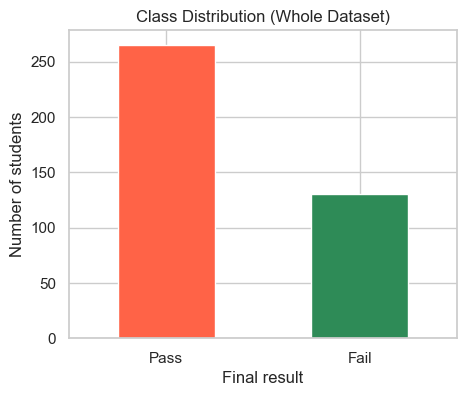

In [4]:
y = (df["G3"] >= PASS_THRESHOLD).astype(int)

LEAKY_COLS = ["G1", "G2", "G3", "past_grades"]          # grades are excluded in the main scenario
FEATURES = [c for c in df.columns if c not in LEAKY_COLS]
FEATURES_WITH_GRADES = [c for c in df.columns if c not in ["G3", "past_grades"]]

X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURES_WITH_GRADES], y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows | Features (main scenario): {len(FEATURES)}")
print(f"Pass rate - train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

counts = y.value_counts().rename(index={0: "Fail", 1: "Pass"})
ax = counts.plot(kind="bar", color=["tomato", "seagreen"], figsize=(5, 4))
ax.set_title("Class Distribution (Whole Dataset)")
ax.set_xlabel("Final result")
ax.set_ylabel("Number of students")
plt.xticks(rotation=0)
plt.show()

## 3. Effect of the Tree Depth (Task 4a)

For each `max_depth` we compute the training accuracy and the **cross-validated** accuracy (5-fold stratified, repeated 3 times) on the training set only. A big gap between the two curves signals overfitting.

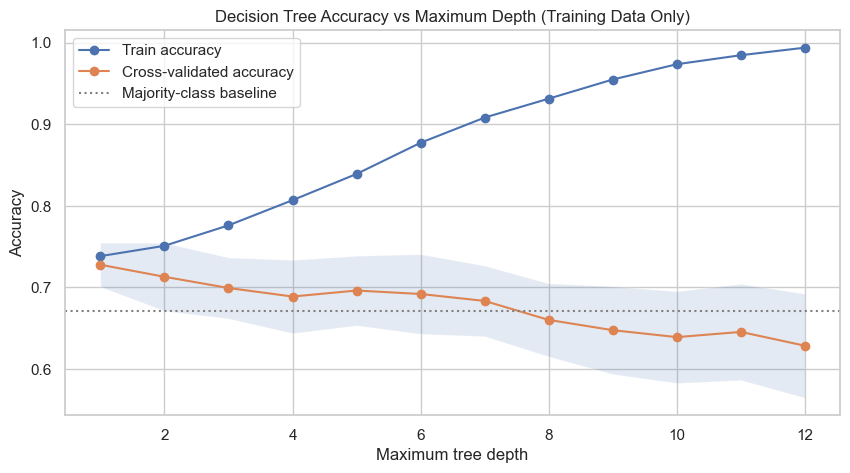

,max_depth,train_acc,cv_acc,cv_std
0,1,0.738,0.728,0.027
1,2,0.751,0.713,0.042
2,3,0.776,0.699,0.037
3,4,0.807,0.689,0.045
4,5,0.839,0.696,0.043
5,6,0.877,0.692,0.049
6,7,0.908,0.683,0.043
7,8,0.931,0.660,0.045
8,9,0.955,0.648,0.054
9,10,0.974,0.639,0.056


In [5]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
N_FOLDS = cv.get_n_splits()
MAJORITY_ACC = max(y_train.mean(), 1 - y_train.mean())


def cv_accuracy(params, X_tr, y_tr):
    """Train and cross-validated accuracy of a decision tree (training data only)."""
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE, **params)
    res = cross_validate(clf, X_tr, y_tr, cv=cv, scoring="accuracy", return_train_score=True)
    return {"train_acc": res["train_score"].mean(), "cv_acc": res["test_score"].mean(), "cv_std": res["test_score"].std()}


depths = list(range(1, 13))
depth_curve = pd.DataFrame([{"max_depth": d, **cv_accuracy({"max_depth": d}, X_train[FEATURES], y_train)} for d in depths])

plt.figure(figsize=(10, 5))
plt.plot(depth_curve["max_depth"], depth_curve["train_acc"], marker="o", label="Train accuracy")
plt.plot(depth_curve["max_depth"], depth_curve["cv_acc"], marker="o", label="Cross-validated accuracy")
plt.fill_between(depth_curve["max_depth"], depth_curve["cv_acc"] - depth_curve["cv_std"],
                 depth_curve["cv_acc"] + depth_curve["cv_std"], alpha=0.15)
plt.axhline(MAJORITY_ACC, color="gray", linestyle=":", label="Majority-class baseline")
plt.title("Decision Tree Accuracy vs Maximum Depth (Training Data Only)")
plt.xlabel("Maximum tree depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

depth_curve.round(3)

The training accuracy keeps rising with depth (deep trees memorize the training students), while the cross-validated accuracy **falls** as the tree grows. The shallowest trees generalize best: the data contain only a weak signal, and every extra split mostly fits noise.

## 4. Joint Tuning of Depth and Minimum Leaf Size (Task 4b)

`min_samples_leaf` only matters once a tree is deep enough to have small leaves, so depth and leaf size are tuned **together** on a grid, using cross-validation on the training set. The final configuration follows the **one-standard-error rule**: among all configurations whose cross-validated accuracy is within one standard error of the best, choose the simplest (smallest depth) and, within that depth, the highest accuracy.

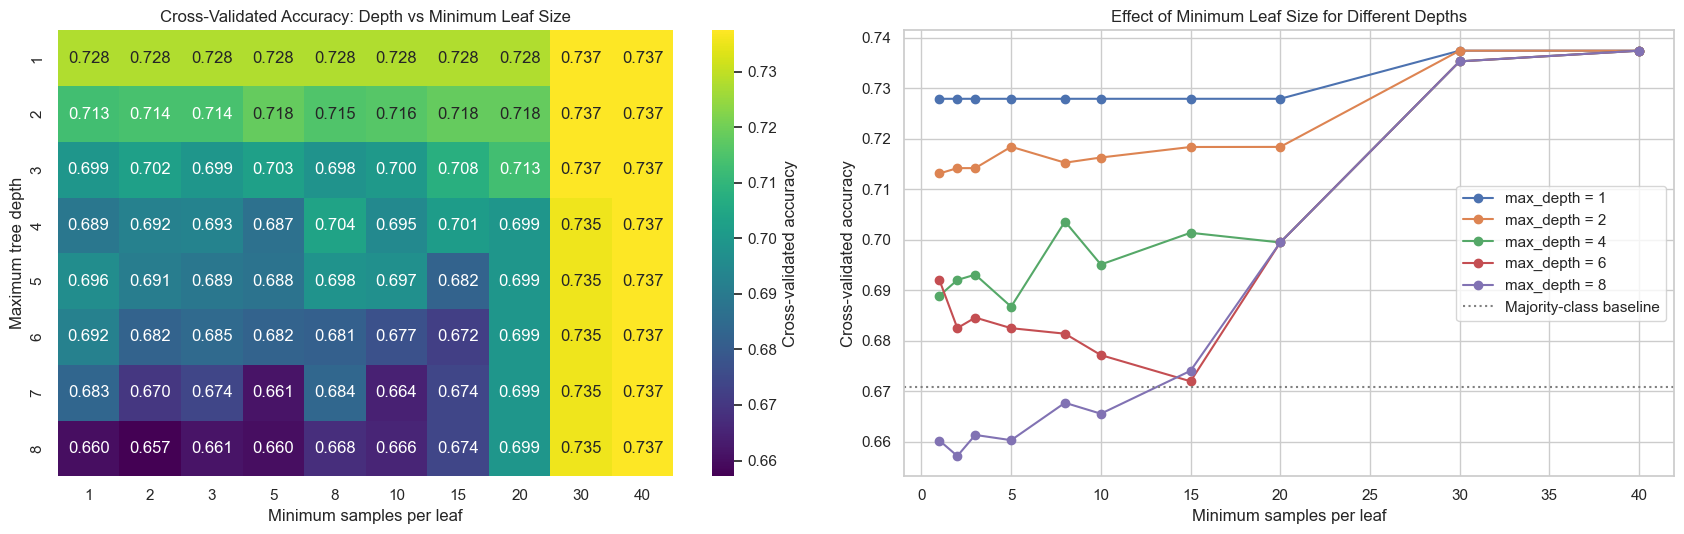

Best raw CV accuracy: 0.737 (max_depth=1, min_samples_leaf=30)
Chosen by the one-standard-error rule: max_depth=1, min_samples_leaf=30


In [6]:
LEAF_VALUES = [1, 2, 3, 5, 8, 10, 15, 20, 30, 40]
DEPTH_VALUES = list(range(1, 9))


def tune_tree(X_tr, y_tr):
    """Grid search over (max_depth, min_samples_leaf) by cross-validation; returns the grid and the 1-SE choice."""
    grid = pd.DataFrame([
        {"max_depth": d, "min_samples_leaf": leaf, **cv_accuracy({"max_depth": d, "min_samples_leaf": leaf}, X_tr, y_tr)}
        for d in DEPTH_VALUES for leaf in LEAF_VALUES
    ])
    best = grid.loc[grid["cv_acc"].idxmax()]
    threshold = best["cv_acc"] - best["cv_std"] / np.sqrt(N_FOLDS)
    candidates = grid[grid["cv_acc"] >= threshold]
    candidates = candidates[candidates["max_depth"] == candidates["max_depth"].min()]
    chosen = candidates.loc[candidates["cv_acc"].idxmax()]
    return grid, int(chosen["max_depth"]), int(chosen["min_samples_leaf"])


grid, best_depth, best_leaf = tune_tree(X_train[FEATURES], y_train)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
heat = grid.pivot(index="max_depth", columns="min_samples_leaf", values="cv_acc")
sns.heatmap(heat, annot=True, fmt=".3f", cmap="viridis", ax=axes[0], cbar_kws={"label": "Cross-validated accuracy"})
axes[0].set_title("Cross-Validated Accuracy: Depth vs Minimum Leaf Size")
axes[0].set_xlabel("Minimum samples per leaf")
axes[0].set_ylabel("Maximum tree depth")

for d in [1, 2, 4, 6, 8]:
    sub = grid[grid["max_depth"] == d]
    axes[1].plot(sub["min_samples_leaf"], sub["cv_acc"], marker="o", label=f"max_depth = {d}")
axes[1].axhline(MAJORITY_ACC, color="gray", linestyle=":", label="Majority-class baseline")
axes[1].set_title("Effect of Minimum Leaf Size for Different Depths")
axes[1].set_xlabel("Minimum samples per leaf")
axes[1].set_ylabel("Cross-validated accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

best_row = grid.loc[grid["cv_acc"].idxmax()]
print(f"Best raw CV accuracy: {best_row['cv_acc']:.3f} (max_depth={int(best_row['max_depth'])}, min_samples_leaf={int(best_row['min_samples_leaf'])})")
print(f"Chosen by the one-standard-error rule: max_depth={best_depth}, min_samples_leaf={best_leaf}")

For deep trees, larger leaves clearly help (the curves rise with `min_samples_leaf`) because they stop the tree from creating rules supported by only a few students. Even so, the simplest trees remain competitive, so the one-standard-error rule selects a very shallow tree.

## 5. Final Model & Evaluation (Tasks 5 and 5a)

The final tree uses the hyper-parameters selected above and is fitted on the full training set. It is evaluated **once** on the test set and compared with two baselines: always predicting the majority class, and a cross-validated L2-regularized logistic regression.

In [7]:
final_tree = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=best_leaf, random_state=RANDOM_STATE)
final_tree.fit(X_train[FEATURES], y_train)

majority = DummyClassifier(strategy="most_frequent").fit(X_train[FEATURES], y_train)

cont_cols = [c for c in ["age", "absences", "study_to_free_ratio"] if c in FEATURES]
log_pre = ColumnTransformer(
    [("continuous", Pipeline([("cap", QuantileCapper(columns=["absences"], quantile=0.95)),
                              ("scale", StandardScaler())]), cont_cols)],
    remainder="passthrough")
logit = Pipeline([
    ("pre", log_pre),
    ("model", LogisticRegressionCV(Cs=np.logspace(-3, 2, 30), cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                                   scoring="roc_auc", max_iter=5000, random_state=RANDOM_STATE)),
]).fit(X_train[FEATURES], y_train)


def evaluate(model, X_te, y_te):
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        "Accuracy": accuracy_score(y_te, pred),
        "Balanced accuracy": balanced_accuracy_score(y_te, pred),
        "Fail recall": recall_score(y_te, pred, pos_label=0),
        "Fail precision": precision_score(y_te, pred, pos_label=0, zero_division=0),
        "F1 (Pass)": f1_score(y_te, pred),
        "ROC-AUC": roc_auc_score(y_te, proba),
    }


comparison = pd.DataFrame({
    "Majority class": evaluate(majority, X_test[FEATURES], y_test),
    "Logistic regression (L2)": evaluate(logit, X_test[FEATURES], y_test),
    f"Decision tree (depth={best_depth}, leaf={best_leaf})": evaluate(final_tree, X_test[FEATURES], y_test),
}).T
comparison.round(3)

,Accuracy,Balanced accuracy,Fail recall,Fail precision,F1 (Pass),ROC-AUC
Majority class,0.671,0.500,0.000,0.000,0.803,0.500
Logistic regression (L2),0.684,0.598,0.346,0.529,0.783,0.606
"Decision tree (depth=1, leaf=30)",0.671,0.588,0.346,0.500,0.772,0.588


=== Final Decision Tree - Classification Report (Test Set) ===
              precision    recall  f1-score   support

        Fail       0.50      0.35      0.41        26
        Pass       0.72      0.83      0.77        53

    accuracy                           0.67        79
   macro avg       0.61      0.59      0.59        79
weighted avg       0.65      0.67      0.65        79



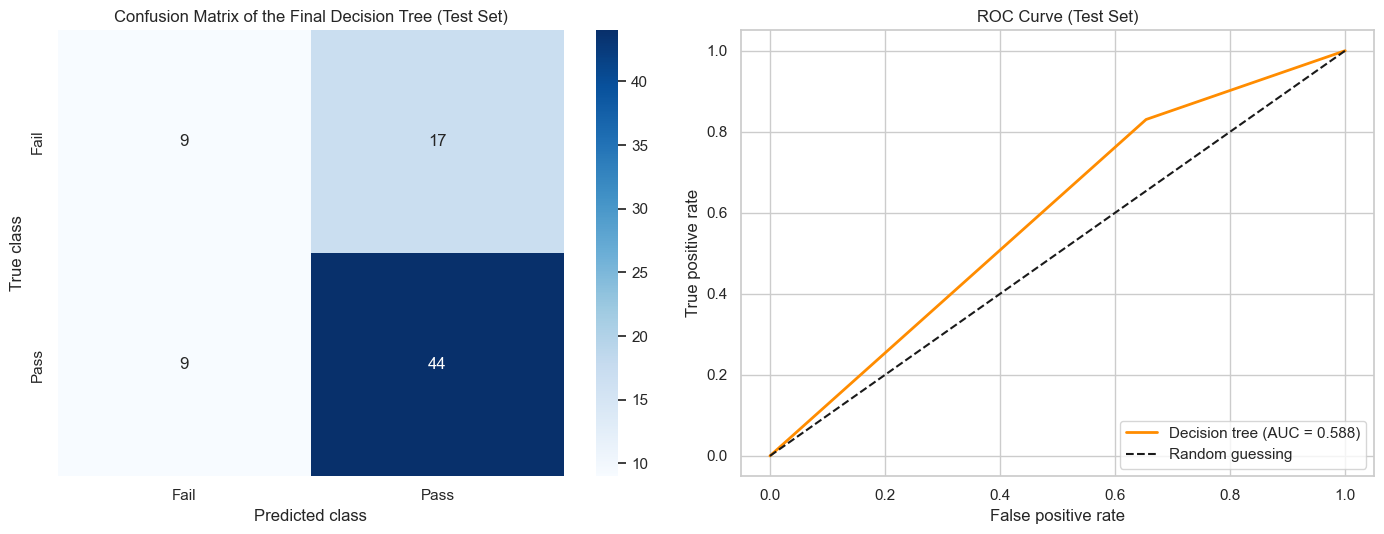

In [8]:
y_pred = final_tree.predict(X_test[FEATURES])
print("=== Final Decision Tree - Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
y_proba = final_tree.predict_proba(X_test[FEATURES])[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix of the Final Decision Tree (Test Set)")
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("True class")

axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"Decision tree (AUC = {roc_auc_score(y_test, y_proba):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random guessing")
axes[1].set_title("ROC Curve (Test Set)")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

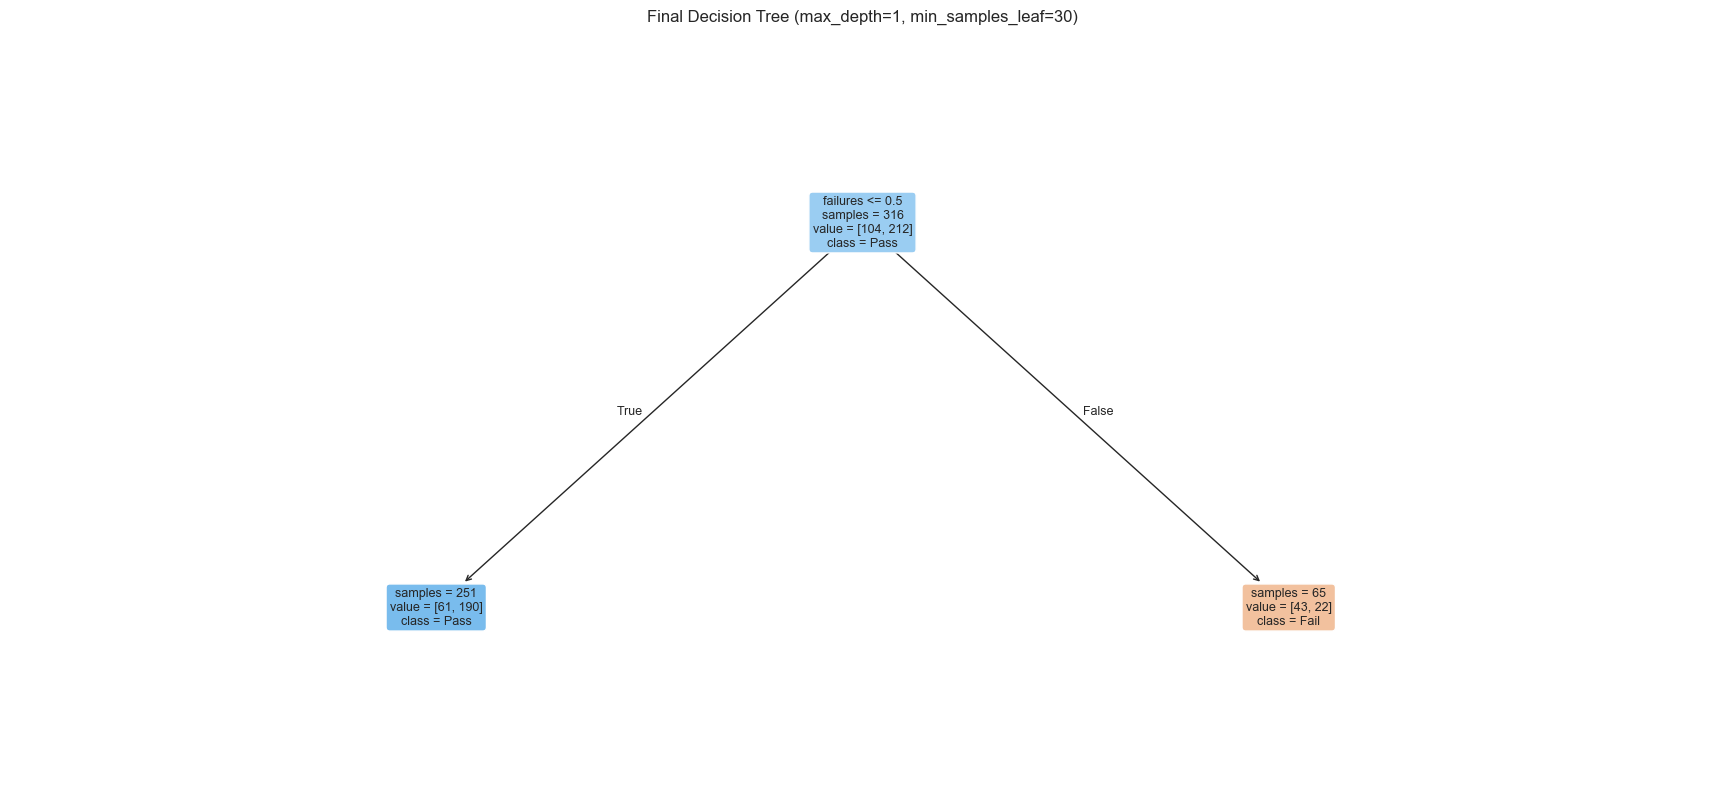

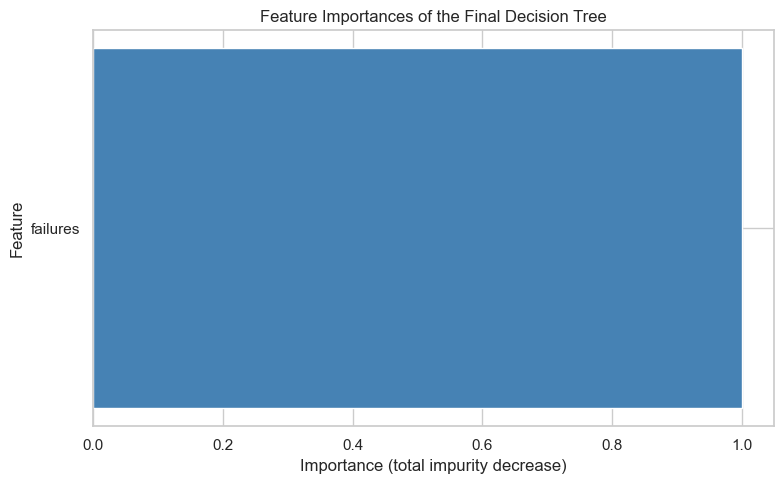

In [9]:
plt.figure(figsize=(22, 10))
plot_tree(final_tree, feature_names=FEATURES, class_names=CLASS_NAMES, filled=True, rounded=True,
          fontsize=9, impurity=False, proportion=False)
plt.title(f"Final Decision Tree (max_depth={best_depth}, min_samples_leaf={best_leaf})")
plt.show()

importances = pd.Series(final_tree.feature_importances_, index=FEATURES).sort_values(ascending=False)
top = importances[importances > 0].head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top.index, top.values, color="steelblue")
plt.title("Feature Importances of the Final Decision Tree")
plt.xlabel("Importance (total impurity decrease)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Reading the results:** without prior grades, accuracy is barely different from the majority-class baseline (which scores about 0.67 simply by predicting "pass" for everyone), so the table should be read mainly through *balanced accuracy*, *fail recall* and ROC-AUC. The baseline finds none of the failing students, whereas the tuned tree and the logistic regression find roughly one in three, at about 50% precision. The test set has only 79 students (26 failing), so differences of a few percentage points are within noise. The tree's advantage over logistic regression is interpretability: each prediction follows from a short chain of questions.

## 6. Decision Rule Induction & Comparison (Task 6)

A decision tree can be turned into IF-THEN rules: every leaf is one rule (the path from the root to that leaf). Here we:
1. Fit a slightly deeper tree (depth 4) **on the training data only** and extract all leaf rules with their training support and precision.
2. Build a compact **rule-based classifier**: keep only the *rules that predict "Fail"* and are supported by enough training students, and predict "Pass" by default. Repeated conditions on the same feature are merged to keep the rules readable.
3. Compare the rule-based classifier with the tuned tree and the majority baseline on the test set.

This mirrors a practical use case: a short list of rules that flags at-risk students.

In [10]:
def extract_rules(clf, feature_names):
    """Return every leaf of a fitted tree as an IF-THEN rule with training statistics."""
    t = clf.tree_
    rules = []

    def recurse(node, conditions):
        if t.children_left[node] == t.children_right[node]:      # leaf
            proportions = t.value[node][0] / t.value[node][0].sum()
            rules.append({
                "conditions": conditions,
                "n_train": int(t.n_node_samples[node]),
                "p_fail": float(proportions[0]),
                "prediction": CLASS_NAMES[int(np.argmax(proportions))],
            })
            return
        feat, thr = feature_names[t.feature[node]], t.threshold[node]
        recurse(t.children_left[node], conditions + [(feat, "<=", thr)])
        recurse(t.children_right[node], conditions + [(feat, ">", thr)])

    recurse(0, [])
    return rules


def simplify(conditions):
    """Merge repeated conditions on the same feature into its tightest lower/upper bound."""
    bounds = {}
    for feat, op, thr in conditions:
        lo, hi = bounds.get(feat, (-np.inf, np.inf))
        bounds[feat] = (max(lo, thr), hi) if op == ">" else (lo, min(hi, thr))
    out = []
    for feat, (lo, hi) in bounds.items():
        if np.isfinite(lo):
            out.append((feat, ">", lo))
        if np.isfinite(hi):
            out.append((feat, "<=", hi))
    return out


def rule_text(conditions):
    return " AND ".join(f"{f} {op} {thr:.2f}" for f, op, thr in conditions) or "TRUE"


def rule_mask(X, conditions):
    mask = pd.Series(True, index=X.index)
    for feat, op, thr in conditions:
        mask &= (X[feat] <= thr) if op == "<=" else (X[feat] > thr)
    return mask


rule_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE).fit(X_train[FEATURES], y_train)
print(export_text(rule_tree, feature_names=FEATURES, max_depth=4))

|--- failures <= 0.50
|   |--- absences <= 21.50
|   |   |--- schoolsup <= 0.50
|   |   |   |--- absences <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- absences >  0.50
|   |   |   |   |--- class: 1
|   |   |--- schoolsup >  0.50
|   |   |   |--- Mjob_services <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Mjob_services >  0.50
|   |   |   |   |--- class: 1
|   |--- absences >  21.50
|   |   |--- class: 0
|--- failures >  0.50
|   |--- failures <= 1.50
|   |   |--- absences <= 1.00
|   |   |   |--- Dalc <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- Dalc >  1.50
|   |   |   |   |--- class: 0
|   |   |--- absences >  1.00
|   |   |   |--- goout <= 2.50
|   |   |   |   |--- class: 1
|   |   |   |--- goout >  2.50
|   |   |   |   |--- class: 0
|   |--- failures >  1.50
|   |   |--- traveltime <= 1.50
|   |   |   |--- class: 0
|   |   |--- traveltime >  1.50
|   |   |   |--- Fjob_other <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Fjob_other >  0.50
|   | 

In [11]:
all_rules = pd.DataFrame(extract_rules(rule_tree, FEATURES))
all_rules["conditions"] = all_rules["conditions"].map(simplify)
all_rules["rule"] = all_rules["conditions"].map(rule_text)
all_rules["precision_of_prediction"] = np.where(all_rules["prediction"] == "Fail", all_rules["p_fail"], 1 - all_rules["p_fail"])
display(all_rules[["rule", "prediction", "n_train", "precision_of_prediction"]].sort_values("n_train", ascending=False).round(3))

,rule,prediction,n_train,precision_of_prediction
1,failures <= 0.50 AND absences > 0.50 AND absen...,Pass,152,0.855
0,failures <= 0.50 AND absences <= 0.50 AND scho...,Pass,62,0.677
2,failures <= 0.50 AND absences <= 21.50 AND sch...,Fail,20,0.600
8,failures > 0.50 AND failures <= 1.50 AND absen...,Fail,20,0.500
9,failures > 1.50 AND traveltime <= 1.50,Fail,15,1.000
3,failures <= 0.50 AND absences <= 21.50 AND sch...,Pass,11,0.818
5,failures > 0.50 AND failures <= 1.50 AND absen...,Fail,8,0.625
4,failures <= 0.50 AND absences > 21.50,Fail,6,0.833
11,failures > 1.50 AND traveltime > 1.50 AND Fjob...,Fail,6,0.500
7,failures > 0.50 AND failures <= 1.50 AND absen...,Pass,6,1.000


In [12]:
MIN_SUPPORT = 10      # a rule must cover at least this many training students
MIN_PRECISION = 0.50  # and at least this share of them must have failed (the leaf must predict Fail)

fail_rules = all_rules[(all_rules["prediction"] == "Fail") & (all_rules["n_train"] >= MIN_SUPPORT)
                       & (all_rules["p_fail"] >= MIN_PRECISION)]
print(f"Selected {len(fail_rules)} 'Fail' rules (support >= {MIN_SUPPORT}, precision >= {MIN_PRECISION}):")
for _, r in fail_rules.iterrows():
    print(f"  IF {r['rule']}  THEN Fail   (n = {r['n_train']}, precision = {r['p_fail']:.2f})")
print("  ELSE Pass (default rule)")


def rule_based_predict(X, rules):
    """Predict Fail (0) if any selected rule fires, otherwise Pass (1)."""
    fired = pd.Series(False, index=X.index)
    for conditions in rules["conditions"]:
        fired |= rule_mask(X, conditions)
    return np.where(fired, 0, 1)

Selected 3 'Fail' rules (support >= 10, precision >= 0.5):
  IF failures <= 0.50 AND absences <= 21.50 AND schoolsup > 0.50 AND Mjob_services <= 0.50  THEN Fail   (n = 20, precision = 0.60)
  IF failures > 0.50 AND failures <= 1.50 AND absences > 1.00 AND goout > 2.50  THEN Fail   (n = 20, precision = 0.50)
  IF failures > 1.50 AND traveltime <= 1.50  THEN Fail   (n = 15, precision = 1.00)
  ELSE Pass (default rule)


In [13]:
def summarize(pred):
    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced accuracy": balanced_accuracy_score(y_test, pred),
        "Fail recall": recall_score(y_test, pred, pos_label=0),
        "Fail precision": precision_score(y_test, pred, pos_label=0, zero_division=0),
    }

rule_pred = rule_based_predict(X_test[FEATURES], fail_rules) if len(fail_rules) else np.ones(len(X_test), dtype=int)
rule_comparison = pd.DataFrame({
    "Majority class": summarize(majority.predict(X_test[FEATURES])),
    f"Rule-based classifier ({len(fail_rules)} Fail rules)": summarize(rule_pred),
    f"Tuned decision tree (depth={best_depth}, leaf={best_leaf})": summarize(final_tree.predict(X_test[FEATURES])),
    "Depth-4 tree used for rule extraction": summarize(rule_tree.predict(X_test[FEATURES])),
}).T
rule_comparison.round(3)

,Accuracy,Balanced accuracy,Fail recall,Fail precision
Majority class,0.671,0.500,0.000,0.000
Rule-based classifier (3 Fail rules),0.658,0.569,0.308,0.471
"Tuned decision tree (depth=1, leaf=30)",0.671,0.588,0.346,0.500
Depth-4 tree used for rule extraction,0.658,0.598,0.423,0.478


**Reading the comparison:** the rule-based classifier is much simpler than a tree (a handful of readable conditions plus a default), so any accuracy it gives up should be weighed against its transparency. The *Fail recall* and *Fail precision* columns show how well the rules identify the students who actually fail, which is the practically relevant question for an early-warning use.

## 7. How Much Do Earlier Grades Add?

For comparison, we repeat the depth/leaf tuning (training data only) in the scenario where `G1` and `G2` are available, and evaluate once on the same test set.

In [14]:
grid_g, depth_g, leaf_g = tune_tree(X_train[FEATURES_WITH_GRADES], y_train)

tree_g = DecisionTreeClassifier(max_depth=depth_g, min_samples_leaf=leaf_g, random_state=RANDOM_STATE)
tree_g.fit(X_train[FEATURES_WITH_GRADES], y_train)

scenario_comparison = pd.DataFrame({
    f"Without G1/G2 (depth={best_depth}, leaf={best_leaf})": evaluate(final_tree, X_test[FEATURES], y_test),
    f"With G1/G2 (depth={depth_g}, leaf={leaf_g})": evaluate(tree_g, X_test[FEATURES_WITH_GRADES], y_test),
}).T
display(scenario_comparison.round(3))

top_g = pd.Series(tree_g.feature_importances_, index=FEATURES_WITH_GRADES).sort_values(ascending=False).head(4)
print("Top features when grades are available:")
print(top_g.round(3).to_string())

,Accuracy,Balanced accuracy,Fail recall,Fail precision,F1 (Pass),ROC-AUC
"Without G1/G2 (depth=1, leaf=30)",0.671,0.588,0.346,0.500,0.772,0.588
"With G1/G2 (depth=1, leaf=1)",0.873,0.896,0.962,0.735,0.898,0.896


Top features when grades are available:
G2         1.0
school     0.0
age        0.0
address    0.0


## 8. Summary

In [15]:
final_summary = pd.DataFrame({
    "Majority class": summarize(majority.predict(X_test[FEATURES])),
    "Logistic regression (L2)": summarize(logit.predict(X_test[FEATURES])),
    f"Decision tree (depth={best_depth}, leaf={best_leaf})": summarize(final_tree.predict(X_test[FEATURES])),
    f"Rule-based classifier ({len(fail_rules)} Fail rules)": summarize(rule_pred),
    f"Decision tree with G1/G2 (depth={depth_g}, leaf={leaf_g})": summarize(tree_g.predict(X_test[FEATURES_WITH_GRADES])),
}).T
print("Test-set comparison of all classifiers:")
final_summary.round(3)

Test-set comparison of all classifiers:


,Accuracy,Balanced accuracy,Fail recall,Fail precision
Majority class,0.671,0.500,0.000,0.000
Logistic regression (L2),0.684,0.598,0.346,0.529
"Decision tree (depth=1, leaf=30)",0.671,0.588,0.346,0.500
Rule-based classifier (3 Fail rules),0.658,0.569,0.308,0.471
"Decision tree with G1/G2 (depth=1, leaf=1)",0.873,0.896,0.962,0.735


**Conclusions**
- Hyper-parameters were chosen by cross-validation on the training set (not on the test set), so the reported test results are an unbiased single estimate. Choosing them on the test set, as is easy to do by accident, would overstate performance.
- Background and behavioural features give only limited power to separate students who pass from those who fail. Cross-validation selects a **single split on `failures`** (any earlier class failure predicts "fail"); deeper trees overfit, and larger leaves help only the deeper trees. The cross-validated accuracy (about 0.73) is higher than the test accuracy (0.67), which shows how noisy an estimate from a 79-student test set is.
- `failures` (number of past class failures) is the most informative non-grade feature. The rule extraction turns the tree into a short list of understandable conditions for flagging at-risk students.
- When `G1` and `G2` are available, classification becomes far more accurate (section 7), confirming that earlier grades are the strongest signal of the final outcome.